# Outlier Detetction


# Customer Spending dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:\CODES\Data Science\DATA\customer_spending - customer_spending.csv")

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_15152\3718039208.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("D:\CODES\Data Science\DATA\customer_spending - customer_spending.csv")


In [3]:
df.head()

,customer_id,spending_amount
0,Cust_1,164
1,Cust_2,145
2,Cust_3,169
3,Cust_4,195
4,Cust_5,142


In [4]:
df['customer_id'].isnull().sum()

np.int64(0)

In [5]:
df.isnull().sum()

customer_id        0
spending_amount    0
dtype: int64

In [6]:
df.describe()

,spending_amount
count,205.000000
mean,156.653659
std,93.202037
min,5.000000
25%,128.000000
50%,150.000000
75%,165.000000
max,1200.000000


Text(0.5, 1.0, 'Spending Amount of Customer')

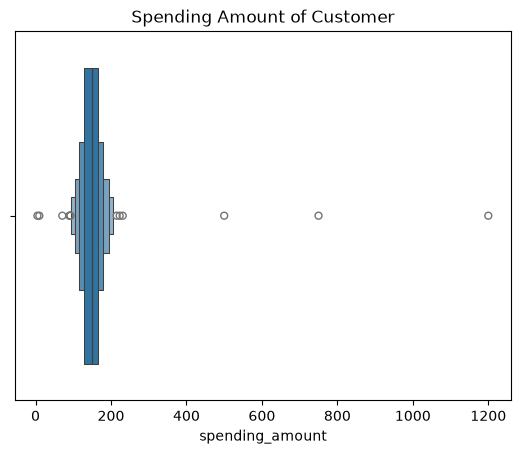

In [7]:
sns.boxenplot(x = df['spending_amount'])
plt.title("Spending Amount of Customer")

Text(0, 0.5, 'NUMBER OF CUSTOMER')

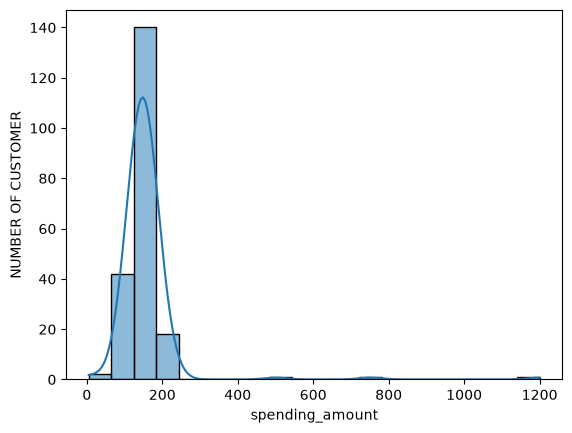

In [9]:
sns.histplot(df['spending_amount'],bins=20,kde=True)
plt.ylabel("NUMBER OF CUSTOMER")

In [12]:
#Detect outlier using quantile method

low_threshold = df['spending_amount'].quantile(0.05)
high_threshold = df['spending_amount'].quantile(0.95)
print(low_threshold)
print(high_threshold)

103.2
196.79999999999998


In [16]:
outliers = df[(df['spending_amount'] < low_threshold) | (df['spending_amount'] > high_threshold)]
print(outliers)
outliers.count()

    customer_id  spending_amount
6        Cust_7              197
13      Cust_14               92
14      Cust_15               98
31      Cust_32              205
37      Cust_38               91
49      Cust_50               97
74      Cust_75               71
79      Cust_80               90
106    Cust_107              206
110    Cust_111               92
113    Cust_114              223
125    Cust_126              215
130    Cust_131              103
142    Cust_143              101
156    Cust_157              205
167    Cust_168              206
179    Cust_180              231
200    Cust_201                5
201    Cust_202               10
202    Cust_203              500
203    Cust_204              750
204    Cust_205             1200


customer_id        22
spending_amount    22
dtype: int64

In [17]:
df_cleaned = df[(df['spending_amount'] >= low_threshold ) & (df['spending_amount'] <= high_threshold)]
df_cleaned

,customer_id,spending_amount
0,Cust_1,164
1,Cust_2,145
2,Cust_3,169
3,Cust_4,195
4,Cust_5,142
...,...,...
195,Cust_196,161
196,Cust_197,123
197,Cust_198,154
198,Cust_199,151


<Axes: xlabel='spending_amount', ylabel='Count'>

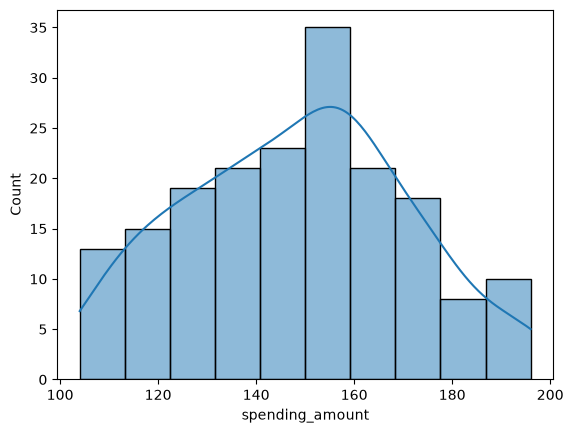

In [27]:
sns.histplot(df_cleaned['spending_amount'], kde=True, bins=10)

In [21]:
df.shape

(205, 2)

In [22]:
df_cleaned.shape

(183, 2)

Text(0.5, 1.0, 'Spending Amount of Customer')

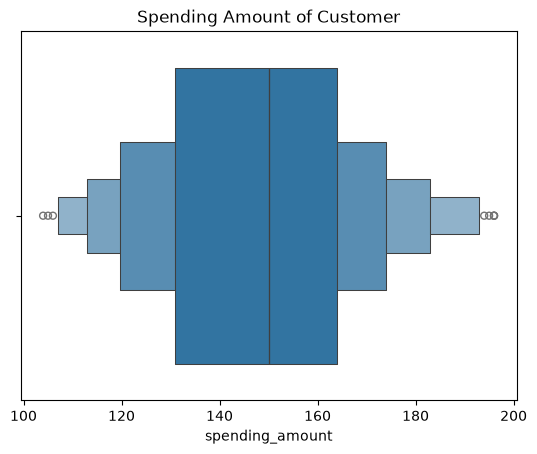

In [25]:
sns.boxenplot(x = df_cleaned['spending_amount'])
plt.title("Spending Amount of Customer")

# Student Test Score


In [30]:
df_student = pd.read_csv(r"D:\CODES\Data Science\DATA\student_test_scores - student_test_scores.csv")
df_student.head()
# df_student.head()

,student_id,test_score
0,S_1,89.967142
1,S_2,83.617357
2,S_3,91.476885
3,S_4,100.000000
4,S_5,82.658466


In [35]:
df_student.describe()

,test_score
count,100.000000
mean,83.366449
std,14.453688
min,8.000000
25%,78.874401
50%,84.061708
75%,90.598391
max,115.000000


In [36]:
df_student.shape

(100, 2)

In [37]:
df_student.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  100 non-null    str    
 1   test_score  100 non-null    float64
dtypes: float64(1), str(1)
memory usage: 2.1 KB


<Axes: xlabel='test_score', ylabel='Count'>

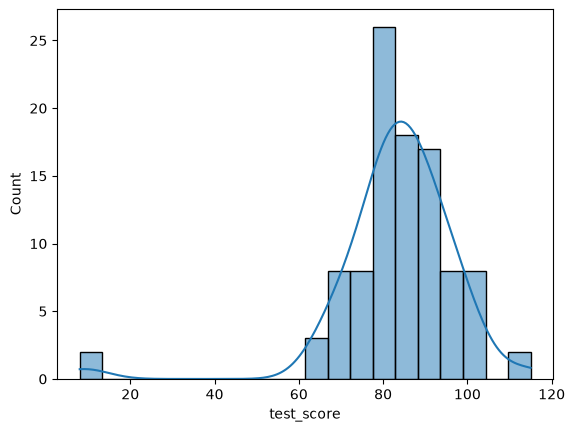

In [38]:
sns.histplot(df_student['test_score'], kde=True)

In [ ]:
lower = df_student['test_score'].quantile(0.5)
higher = df_student['test_score'].quantile(0.95)
print(lower)
print(higher)

84.06170798
100.0


<Axes: >

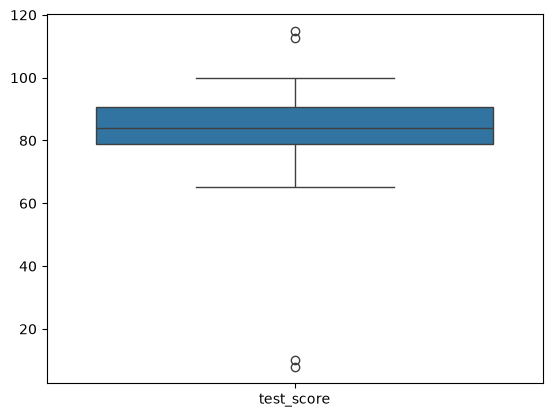

In [41]:
sns.boxplot(data=df_student)

In [44]:
outliers = df_student[(df_student['test_score'] < lower) | (df_student['test_score'] > higher)]
print(outliers)
outliers.count()

   student_id  test_score
1         S_2   83.617357
4         S_5   82.658466
5         S_6   10.000000
8         S_9   80.305256
10       S_11   80.365823
11       S_12   80.342702
13       S_14   65.867198
14       S_15   67.750822
16       S_17   74.871689
18       S_19   75.919759
19       S_20   70.876963
21       S_22   82.742237
23       S_24   70.752518
24       S_25   79.556173
25       S_26    8.000000
26       S_27   73.490064
28       S_29   78.993613
29       S_30   82.083062
30       S_31   78.982934
33       S_34   74.422891
35       S_36  115.000000
37       S_38   65.403299
38       S_39   71.718140
42       S_43   83.843517
43       S_44   81.988963
44       S_45   70.214780
45       S_46   77.801558
46       S_47   80.393612
49       S_50   67.369598
51       S_52   81.149177
52       S_53   78.230780
56       S_57   76.607825
57       S_58   81.907876
60       S_61   80.208258
61       S_62   83.143410
62       S_63   73.936650
63       S_64   73.037934
69       S_7

student_id    52
test_score    52
dtype: int64

In [47]:
df_student_cleaned = df_student[(df_student['test_score'] >= lower) & (df_student['test_score'] <= higher)]
df_student_cleaned

,student_id,test_score
0,S_1,89.967142
2,S_3,91.476885
3,S_4,100.000000
6,S_7,100.000000
7,S_8,92.674347
9,S_10,90.425600
12,S_13,87.419623
15,S_16,100.000000
17,S_18,88.142473
20,S_21,99.656488


<Axes: xlabel='test_score', ylabel='Count'>

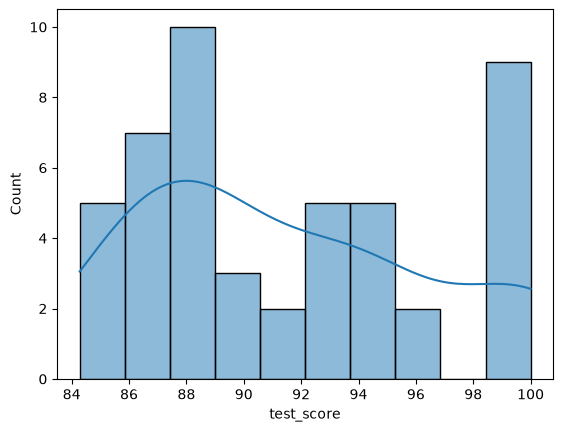

In [51]:
sns.histplot(df_student_cleaned['test_score'], kde=True,bins = 10)

<Axes: >

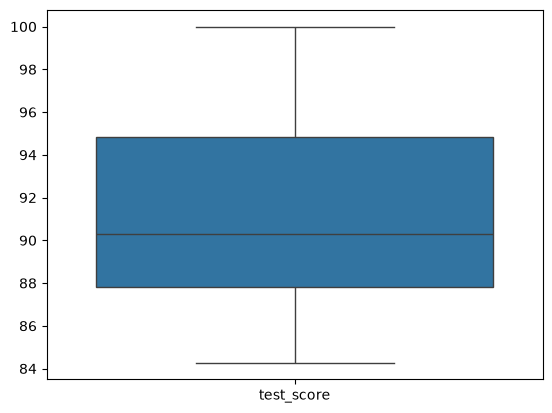

In [50]:
sns.boxplot(data=df_student_cleaned)